In [1]:
import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns
import random


from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [11, 12, 65],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }





EC130_200 [1, 13]
EC133_200 [282, 291, 292, 293]
EC135_200 [303]
EC137_200 [257, 258, 259, 269]
EC143_200 [339]
EC157_200 [321, 332, 333, 334]
EC162_200 [85, 86]
EC175_200 [301, 302]
EC183_200 [290]
EC186_200 [299, 300, 301]
EC187_200 [309, 310]
EC191_200 [2, 3, 4]
EC196_200 [300, 301, 303]
EC219_200 [399, 400, 402, 403]
EC220_200 [53, 54, 76, 77]
EC221_200 [376, 377]
EC222_200 [267, 268, 269, 270]
(31847, 60) (31847,)
(31847, 60)
UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)


/home/dazhang/anaconda3/envs/klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Fri Sep 18 17:51:53 2026 Construct fuzzy simplicial set
Fri Sep 18 17:51:53 2026 Finding Nearest Neighbors
Fri Sep 18 17:51:53 2026 Building RP forest with 14 trees
Fri Sep 18 17:51:56 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Fri Sep 18 17:52:09 2026 Finished Nearest Neighbor Search
Fri Sep 18 17:52:11 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Fri Sep 18 17:52:17 2026 Finished embedding


/home/dazhang/anaconda3/envs/klab/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Min X, Max X:  -4.1483297 9.943624
Min Y, Max Y:  0.8951096 12.604202


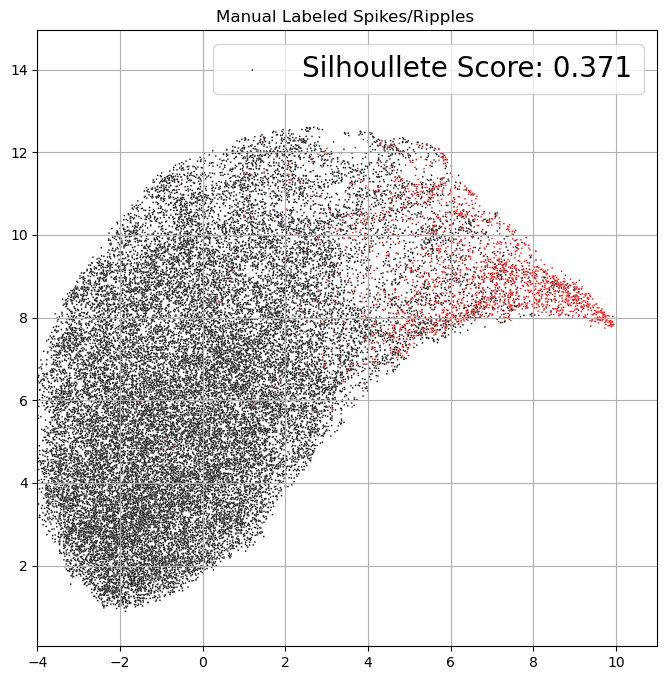

In [2]:

all_specs_label = []
all_specs = np.empty((0, 60))
# all_specs = np.empty((0, 31293))
file_list = []
pathname = '/scratch/dazhang/MATLAB/'
for patient, channal_list in pt_ch_mapping.items():
    print(patient, channal_list)
    path = pathname + patient+'/'
    ls_specs = np.empty((0, 60))
    # ls_specs = np.empty((0, 31293))

    for cur_channel in channal_list:
        cur_channel = str(cur_channel) 
        cur_channel_list = []   
        for filename in glob.glob(os.path.join(path, '*.mat')):
            
                # each_file = 'ls_ripple_'+str(patient)+'_Channel_' + str(cur_channel) + '_binsize_10_Block_'+str(blk)+'.mat'
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(os.path.join(os.getcwd(), filename), 'r') as f: 
                if "Channel_"+str(cur_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs_label = np.concatenate([all_specs_label, [patient]*len(ls_specs)])
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

print(all_specs.shape, all_specs_label.shape)

# exit(0)
test_shape2 = []
all_spikes_label = np.empty((0, 1))
manual_label_spikes = list()
for each_file in file_list:
    patient_name = each_file.split("/")[-2]
    actural_file = each_file.split("/")[-1]
    actural_file_list = actural_file.split("_")
    spike_file_name = pathname + patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])

    with open(spike_file_name, 'r') as f: 
        spikes = loadmat(spike_file_name)['ls_spikes']


    all_spikes_label = np.concatenate([all_spikes_label, spikes])

all_ripples = all_specs

print(all_ripples.shape)

all_vectors = np.asarray(all_ripples)


embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)

#Import required module
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
#Initialize the class object
#930 is good
kmeans = KMeans(n_clusters = 5,random_state = 920, n_init=10)

kmeans_label = kmeans.fit(embedding)
closest, all_points_w_labels = pairwise_distances_argmin_min(kmeans_label.cluster_centers_, embedding)

# print(closest)

actual_score = silhouette_score(embedding, all_spikes_label)


def total_kl_divergence(X, labels):
    X = normalize(X, norm='l1', axis=1)  # Ensure all rows are valid distributions
    unique_labels = np.unique(labels)
    total_kl = 0
    labels = np.ravel(labels)

    for label in unique_labels:
        cluster_points = X[labels == label]
        if cluster_points.shape[0] == 0:
            continue
        centroid = np.mean(cluster_points, axis=0)
        centroid /= np.sum(centroid)  # Normalize to make it a distribution

        for x in cluster_points:
            total_kl += kl_divergence(x, centroid)

    return total_kl

total_kl = total_kl_divergence(embedding, all_spikes_label)




# red: spike
# blue: ripple
c_list = []
for i, txt in enumerate(all_spikes_label):
    spike = all_spikes_label[i]
    if spike == 0:
        # cc = [1, 1, 1]  # Whites
        cc = [0, 0, 0]   # Black
    else:
        cc = [1, 0, 0] 
        # cc = [0, 0, 0]
        # cc = [1, 1, 1]
    c_list.append(cc)


max_x = np.max(embedding[:, 0])  # Find the maximum x-coordinate
embedding[embedding[:, 0] == max_x] 
min_x = np.min(embedding[:, 0])  # Find the maximum x-coordinate
embedding[embedding[:, 0] == min_x] 
print("Min X, Max X: ", min_x, max_x)


max_y = np.max(embedding[:, 1])  # Find the maximum x-coordinate
embedding[embedding[:, 0] == max_y] 
min_y = np.min(embedding[:, 1])  # Find the maximum x-coordinate
embedding[embedding[:, 0] == min_y] 
print("Min Y, Max Y: ",min_y, max_y)


fig, ax = plt.subplots(figsize=(8,8))
ax = sns.scatterplot(x=embedding[:,0], y=embedding[:,1], c=c_list, s=1.5)
ax.legend(["Silhoullete Score: "+str(f"{actual_score:.3f}")], fontsize=20, ncol=1)
# ax.legend(["KL Divergence: "+str(f"{total_kl:.3f}")], fontsize=20, ncol=1)

# ax.axvline(x=max_x, color='green', linestyle='--', label=f"Max X = {max_x:.2f}")
# ax.axvline(x=min_x, color='red', linestyle='--', label=f"Min X = {min_x:.2f}")
# ax.text(max_x, ax.get_ylim()[0] - 0.5, f"{max_x:.2f}", ha='center', va='top', fontsize=12, color='green')
# ax.text(min_x, ax.get_ylim()[0] - 0.5, f"{min_x:.2f}", ha='center', va='top', fontsize=12, color='red')

# ax.axhline(y=max_y, color='blue', linestyle='--', label=f"Max Y = {max_y:.2f}")
# ax.axhline(y=min_y, color='orange', linestyle='--', label=f"Min Y = {min_y:.2f}")
# ax.text(ax.get_xlim()[0], max_y, f"{max_y:.2f}", ha='center', va='top', fontsize=12, color='blue')
# ax.text(ax.get_xlim()[0], min_y, f"{min_y:.2f}", ha='center', va='top', fontsize=12, color='orange')

# ax.set_xticklabels([])
# ax.set_yticklabels([])

ax.grid(True)
ax.axis('equal')

ax.set_xlim(-4, 11)
ax.set_ylim(0, 15)
# ax.set_xticklabels([])
# ax.set_yticklabels([])

ax.title.set_text("Manual Labeled Spikes/Ripples ")
plt.show()
# plt.legend()
# plt.savefig("plot_prob_dots_true_200_only_spike.png")
# plt.savefig("plot_prob_dots_true_200.png")
# plt.close()